# Climate Benchmark: Tesco vs Sainsbury's vs Walmart

## Objective

Compare the climate performance of Tesco, Sainsbury's and Walmart to assess:

1. What climate commitments has each company made?
2. How have emissions changed since their respective baseline years?
3. Where are their largest sources of emissions?
4. Are the reported emissions directly comparable?
5. What can Tesco learn from the approaches of its peers?

---

# 1. Climate Commitments

### What are we trying to understand?

Before comparing emissions performance, we first need to establish **what each company has committed to achieving**.

We will compare:

- Scope 1 & 2 targets
- Scope 3 targets
- Base years
- Target years
- Net-zero commitments
- SBTi validation

### 1.1 Scope 1 & 2 Targets

We first compare each company's operational emissions targets to understand
the scale and timing of their decarbonisation commitments.

In [2]:
import os

os.listdir("../data/raw")

['Alpha-Dashboard-Data-Dictionary.xlsx',
 'cdp',
 'companies-excel.xlsx',
 'README.md',
 'targets-excel.xlsx']

In [3]:
import pandas as pd

targets = pd.read_excel("../data/raw/targets-excel.xlsx")

targets.head()

,row_entry_id,sbti_id,company_name,isin,lei,location,region,sector,organization_type,validation_route,...,target_wording,scope,target_value,type,sub_type,target_classification_short,base_year,target_year,year_type,date_published
0,53070342-40023788,40023788,"""Hytex Plastic"" CJSC",NaN,NaN,Armenia,Europe,Containers and Packaging,SME,SME,...,Hytex Plastic CJSC commits to reduce absolute ...,1+2,50.4%,Absolute,Reduction,1.5°C,2024.0,2032.0,CY,2025-09-18 01:00:00
1,91939371-40026740,40026740,"""Kazakh pharmaceutical company ""MEDSERVICE PL...",NaN,NaN,Kazakhstan,Asia,"Healthcare Providers and Services, and Healthc...",Corporate,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-07-31 01:00:00
2,12859-40009210,40009210,(ACIP) Alexandria Company for Industrial Packages,NaN,NaN,Egypt,Africa,Containers and Packaging,SME,SME,...,(ACIP) Alexandria Company for Industrial Packa...,1+2,25%,Absolute,Reduction,Well-below 2°C,2020.0,2030.0,CY,2022-02-03 01:00:00
3,80318954-40009945,40009945,& Co.,NaN,NaN,Denmark,Europe,Media,SME,SME,...,& Co. commits to reduce scope 1 and scope 2 GH...,1+2,42%,Absolute,Reduction,1.5°C,2022.0,2030.0,CY,2024-01-25 01:00:00
4,88836441-40022773,40022773,&Tradition,NaN,894500RY226L5NMCTT65,Denmark,Europe,"Consumer Durables, Household and Personal Prod...",Corporate,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-03-20 01:00:00


### Identify our benchmark companies

The SBTi dataset contains thousands of organisations. Before analysing climate
targets, we first identify the records corresponding to Tesco, Sainsbury's and
Walmart.

This also allows us to check how each company's name is recorded in the dataset
before filtering the target data.

In [4]:
targets[
    targets["company_name"].str.contains(
        "Tesco|Sainsbury|Walmart",
        case=False,
        na=False
    )
]["company_name"].unique()

<StringArray>
[              'J Sainsbury plc',          'Nabtesco Corporation',
                         'Tesco', 'Vitesco Technologies Group AG',
                  'Walmart Inc.']
Length: 5, dtype: str

### Filter to the benchmark companies

The initial text search returned several partial matches because company names
containing "Tesco" were also identified.

I therefore filter using the exact company names recorded in the SBTi dataset:
Tesco, J Sainsbury plc and Walmart Inc.

In [5]:
companies = ["Tesco", "J Sainsbury plc", "Walmart Inc."]

benchmark_targets = targets[
    targets["company_name"].isin(companies)
]

#benchmark_targets

### Inspect the available target data

Now that the dataset has been filtered to the three benchmark companies, we
inspect the available columns to identify which variables are relevant to
comparing their climate commitments.

In [6]:
benchmark_targets.columns.tolist()

['row_entry_id',
 'sbti_id',
 'company_name',
 'isin',
 'lei',
 'location',
 'region',
 'sector',
 'organization_type',
 'validation_route',
 'action',
 'commitment_type',
 'commitment_deadline',
 'status',
 'reason_for_commitment_extension_or_removal',
 'full_target_language',
 'company_temperature_alignment',
 'target',
 'target_wording',
 'scope',
 'target_value',
 'type',
 'sub_type',
 'target_classification_short',
 'base_year',
 'target_year',
 'year_type',
 'date_published']

### Select variables relevant to Scope 1 & 2 targets

For the operational emissions comparison, we retain only the variables needed
to understand the nature and timing of each company's target.

These include the target scope, reduction value, base year, target year and
current target status. This reduces the wider SBTi dataset to the information
needed for the benchmark.

In [7]:
target_cols = [
    "company_name",
    "status",
    "target",
    "scope",
    "target_value",
    "type",
    "sub_type",
    "base_year",
    "target_year"
]

benchmark_targets[target_cols]

,company_name,status,target,scope,target_value,type,sub_type,base_year,target_year
16706,J Sainsbury plc,Target set,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16707,J Sainsbury plc,NaN,Net-zero,1+2+3,NaN,Net-zero,Other,2018.0,2050.0
16708,J Sainsbury plc,NaN,Near-term,1+2,68%,Absolute,Reduction,2018.0,2030.0
16709,J Sainsbury plc,NaN,Near-term,3,50.4%,Absolute,Reduction,2018.0,2030.0
16710,J Sainsbury plc,NaN,Near-term,3,36.4%,Absolute,Reduction,2018.0,2030.0
16711,J Sainsbury plc,NaN,Near-term,1+2+3,NaN,No-deforestation,Other,2018.0,2025.0
16712,J Sainsbury plc,NaN,Long-term,1+2,100%,Absolute,Reduction,2018.0,2035.0
16713,J Sainsbury plc,NaN,Long-term,3,90%,Absolute,Reduction,2018.0,2050.0
16714,J Sainsbury plc,NaN,Long-term,3,72%,Absolute,Reduction,2018.0,2050.0
32000,Tesco,Target set,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Near-term Scope 1 & 2 targets

Companies may have multiple SBTi targets covering different emissions scopes
and time horizons. To make a like-for-like comparison, we first isolate each
company's near term Scope 1 and Scope 2 emissions reduction target.

The target value represents the percentage reduction committed to relative
to the company's stated base year.

In [8]:
scope12_targets = benchmark_targets[
    (benchmark_targets["target"] == "Near-term") &
    (benchmark_targets["scope"] == "1+2")
][[
    "company_name",
    "target_value",
    "base_year",
    "target_year"
]]

scope12_targets

,company_name,target_value,base_year,target_year
16708,J Sainsbury plc,68%,2018.0,2030.0
32002,Tesco,82.6%,2015.0,2032.0
39161,Walmart Inc.,27.84%,2025.0,2031.0


#### Initial observation

The three companies have different near term Scope 1 and 2 reduction targets:

- **Tesco:** 82.6% reduction from a 2015 base year by 2032.
- **Sainsbury's:** 68% reduction from a 2018 base year by 2030.
- **Walmart:** 27.84% reduction from a 2025 base year by 2031.

The headline reduction percentages should not be compared in isolation. Each
company uses a different base year and target year, meaning the targets cover
different periods.

The next stage therefore considers the time horizon of each target before
drawing comparisons between the companies.

In [9]:
scope12_targets = scope12_targets.copy()

scope12_targets["target_period"] = (
    scope12_targets["target_year"] - scope12_targets["base_year"]
)

scope12_targets

,company_name,target_value,base_year,target_year,target_period
16708,J Sainsbury plc,68%,2018.0,2030.0,12.0
32002,Tesco,82.6%,2015.0,2032.0,17.0
39161,Walmart Inc.,27.84%,2025.0,2031.0,6.0


### Comparing target ambition across different time periods

The three Scope 1 and 2 targets cover different time periods, so the headline
percentage reductions are not directly comparable.

To provide an additional comparison, we calculate the constant annual reduction
rate implied by each target. This represents the approximate percentage by which
emissions would need to decline each year to move from the base year level to
the stated target level.

This is a simplified comparison of target trajectories rather than evidence of
the companies' actual annual emissions reductions.

In [10]:
# Convert target values such as "82.6%" into numbers
scope12_targets["target_value_numeric"] = (
    scope12_targets["target_value"]
    .str.replace("%", "", regex=False)
    .astype(float)
)

# Calculate the implied constant annual reduction rate
scope12_targets["annual_reduction_rate"] = (
    1 - (
        1 - scope12_targets["target_value_numeric"] / 100
    ) ** (1 / scope12_targets["target_period"])
) * 100

scope12_targets

,company_name,target_value,base_year,target_year,target_period,target_value_numeric,annual_reduction_rate
16708,J Sainsbury plc,68%,2018.0,2030.0,12.0,68.00,9.058419
32002,Tesco,82.6%,2015.0,2032.0,17.0,82.60,9.775096
39161,Walmart Inc.,27.84%,2025.0,2031.0,6.0,27.84,5.292853


#### Interpretation

Adjusting for the different target periods provides additional context to the
headline reduction commitments.

- **Tesco's** 82.6% reduction target implies an approximately **9.8% annual
  reduction** over its 17 year target period.
- **Sainsbury's** 68% target implies an approximately **9.1% annual reduction**
  over 12 years.
- **Walmart's** 27.84% target implies an approximately **5.3% annual reduction**
  over six years.

This shows that Tesco and Sainsbury's have more similar implied annual reduction
rates than their headline target percentages initially suggest.

These figures represent simplified constant annual reduction trajectories, not
the companies' actual YoY emissions reductions.

### Visualising the implied annual reduction rate

To account for differences in base years and target years, the chart below
compares the constant annual emissions reduction rate implied by each company's
near-term Scope 1 and 2 target.

A higher rate represents a steeper annual reduction trajectory required to
reach the stated target.

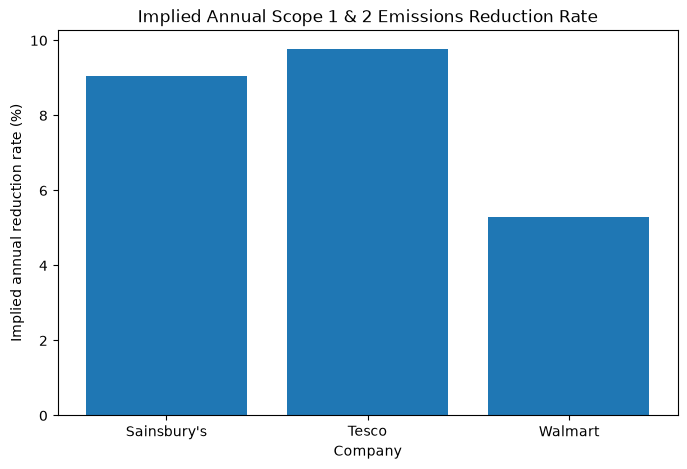

In [11]:
import matplotlib.pyplot as plt

# Shorter company names for the chart
scope12_targets["company"] = (
    scope12_targets["company_name"]
    .replace({
        "J Sainsbury plc": "Sainsbury's",
        "Walmart Inc.": "Walmart"
    })
)

plt.figure(figsize=(8, 5))

plt.bar(
    scope12_targets["company"],
    scope12_targets["annual_reduction_rate"]
)

plt.ylabel("Implied annual reduction rate (%)")
plt.xlabel("Company")
plt.title("Implied Annual Scope 1 & 2 Emissions Reduction Rate")

plt.show()

### Interpretation

Tesco has the steepest implied annual reduction trajectory, requiring an
approximately 9.8% annual reduction in Scope 1 and 2 emissions to achieve its
82.6% reduction target between 2015 and 2032.

Sainsbury's follows closely, with an implied annual reduction rate of
approximately 9.1% to achieve a 68% reduction between 2018 and 2030.

Walmart's near-term target implies a lower annual reduction rate of
approximately 5.3%, although its target period is considerably shorter,
running from 2025 to 2031.

This comparison helps normalise differences in target magnitude and target
period. However, it compares the ambition implied by the targets rather than
actual emissions performance.

---

## 1.2 Scope 3 Targets

We next compare the companies' value chain emissions targets.

Scope 3 emissions arise from activities within a company's value chain rather
than from sources directly controlled by the company. For large retailers,
these emissions can represent a substantial share of the overall climate
footprint.

In [12]:
scope3_targets = benchmark_targets[
    (benchmark_targets["target"] == "Near-term") &
    (benchmark_targets["scope"] == "3")
]

scope3_targets[
    ["company_name", "target_value", "base_year", "target_year"]
]

,company_name,target_value,base_year,target_year
16709,J Sainsbury plc,50.4%,2018.0,2030.0
16710,J Sainsbury plc,36.4%,2018.0,2030.0
32003,Tesco,55%,2019.0,2032.0
32004,Tesco,39.4%,2019.0,2032.0
39162,Walmart Inc.,NaN,2016.0,2031.0


In [14]:
pd.set_option("display.max_colwidth", None)

scope3_targets[
    ["company_name", "target_value", "base_year", "target_year", "target_wording"]
]

,company_name,target_value,base_year,target_year,target_wording
16709,J Sainsbury plc,50.4%,2018.0,2030.0,"Energy & Industry: J Sainsbury plc also commits to reduce absolute scope 3 GHG emissions from purchased goods and services, upstream transportation and distribution and use of sold products 50.4% within the same timeframe."
16710,J Sainsbury plc,36.4%,2018.0,2030.0,FLAG: J Sainsbury plc commits to reduce absolute scope 3 FLAG GHG emissions 36.4% by FY2030 from a FY2018 base year**.\n**The target includes FLAG emissions and removals.
32003,Tesco,55%,2019.0,2032.0,Tesco PLC also commits to reduce absolute scope 3 GHG emissions 55% by FY2032 from a FY2019 base year.
32004,Tesco,39.4%,2019.0,2032.0,FLAG: Tesco PLC commits to reduce absolute scope 3 FLAG GHG emissions 39.4% by FY2032 from a FY2019 base year.** **Target includes FLAG emissions and removals.
39162,Walmart Inc.,NaN,2016.0,2031.0,Walmart will work to reduce CO2e emissions from upstream and downstream scope 3 sources by one billion tonnes by FY2031 from a FY2016 base year.


### Understanding the Scope 3 targets

### Scope 3 Target Comparison

Tesco and Sainsbury's report separate targets for general Scope 3 and FLAG
(Forest, Land and Agriculture) emissions.

Walmart uses a different approach, targeting one billion tonnes of CO2e
across its value chain rather than a percentage reduction.

Therefore, Walmart's Scope 3 target is not directly comparable with the
percentage based targets of Tesco and Sainsbury's.

In [15]:
scope3_general = scope3_targets[
    scope3_targets["target_wording"].str.contains(
        "FLAG", case=False, na=False
    ) == False
]

scope3_general[
    ["company_name", "target_value", "base_year", "target_year"]
]

,company_name,target_value,base_year,target_year
16709,J Sainsbury plc,50.4%,2018.0,2030.0
32003,Tesco,55%,2019.0,2032.0
39162,Walmart Inc.,NaN,2016.0,2031.0


In [16]:
scope3_comparison = scope3_general[
    ["company_name", "target_value", "base_year", "target_year"]
].copy()

scope3_comparison["target_type"] = [
    "Percentage reduction",
    "Percentage reduction",
    "Absolute CO2e reduction"
]

scope3_comparison

,company_name,target_value,base_year,target_year,target_type
16709,J Sainsbury plc,50.4%,2018.0,2030.0,Percentage reduction
32003,Tesco,55%,2019.0,2032.0,Percentage reduction
39162,Walmart Inc.,NaN,2016.0,2031.0,Absolute CO2e reduction


## 1.3 Net-Zero Commitments

Finally, compare each company's overall net zero commitment and target year.

In [17]:
netzero_targets = benchmark_targets[
    benchmark_targets["target"] == "Net-zero"
]

netzero_targets[
    ["company_name", "scope", "base_year", "target_year", "target_wording"]
]

,company_name,scope,base_year,target_year,target_wording
16707,J Sainsbury plc,1+2+3,2018.0,2050.0,J Sainsbury plc commits to reach net-zero greenhouse gas emissions across the value chain by FY2050.
32001,Tesco,1+2+3,2015.0,2050.0,Tesco PLC commits to reach net-zero GHG emissions across the value chain by FY2050.


### Interpretation

Tesco and Sainsbury's both have SBTi net zero targets covering Scopes 1, 2
and 3 by 2050.

No equivalent Walmart net zero target appears in the SBTi dataset used here.
This should not be interpreted as evidence that Walmart has no wider
net zero commitment.

---

# 2. Emissions Performance

## 2.1 Scope 1 & 2 Emissions

I now move from climate commitments to actual emissions performance. First, compare changes in Scope 1 and 2 emissions against each company's
respective baseline.

In [18]:
os.listdir("../data/raw")

['Alpha-Dashboard-Data-Dictionary.xlsx',
 'cdp',
 'companies-excel.xlsx',
 'README.md',
 'targets-excel.xlsx']

In [19]:
os.makedirs("../data/processed", exist_ok=True)

### Data approach

SBTi data describes company climate targets but does not provide the annual
emissions data required for performance analysis.

Reported Scope 1 and 2 emissions will therefore be compiled from company
disclosures into a standardised dataset before comparison.

### 2.1.1 Walmart

Walmart's reported Scope 1 and Scope 2 emissions are used to assess actual
operational emissions performance relative to its baseline and climate targets.

In [25]:
walmart_emissions_2026 = pd.DataFrame({
    "company": ["Walmart"],
    "reporting_year": ["FY2026"],

    # Current emissions
    "scope1_tco2e": [None],
    "scope2_location_tco2e": [None],
    "scope2_market_tco2e": [None],

    # Historical performance
    "historical_baseline_year": ["FY2016"],
    "change_from_historical_baseline_pct": [-24.6],
    "scope12_yoy_change_pct": [-7.5],

    # Current SBTi target
    "target_base_year": ["FY2025"],
    "target_year": ["FY2031"],
    "target_reduction_pct": [28]
})

walmart_emissions_2026

walmart_emissions_2026

,company,reporting_year,scope1_tco2e,scope2_location_tco2e,scope2_market_tco2e,historical_baseline_year,change_from_historical_baseline_pct,scope12_yoy_change_pct,target_base_year,target_year,target_reduction_pct
0,Walmart,FY2026,None,None,None,FY2016,-24.6,-7.5,FY2025,FY2031,28


**Source:** Walmart FY2026 ESG Report.

**Note:** Walmart reports historical emissions progress against FY2016, while its
current SBTi Scope 1 & 2 target uses FY2025 as the baseline.

### Scope 2 accounting

Both location based and market based Scope 2 emissions are retained. However, market based Scope 2 will be used for target performance comparisons where
this is consistent with each company's target accounting approach.

### 2.1.2 Tesco

Tesco's reported Scope 1 and Scope 2 emissions are used to assess actual
operational emissions performance relative to its baseline and climate targets.

In [23]:
tesco_emissions = pd.DataFrame({
    "company": ["Tesco"],
    "reporting_year": ["2025/26"],
    "scope1_tco2e": [734003],
    "scope2_location_tco2e": [498345],
    "scope2_market_tco2e": [5789]
})

tesco_emissions
tesco_emissions.to_csv(
    "../data/processed/tesco_emissions.csv",
    index=False
)

tesco_emissions


,company,reporting_year,scope1_tco2e,scope2_location_tco2e,scope2_market_tco2e
0,Tesco,2025/26,734003,498345,5789


**Source:** Tesco Sustainability Report 2026.  
2025/26 52-week figures are used for comparability with prior reporting periods.

### 2.1.2 Sainsbury's

Sainsbury's latest reported Scope 1 and Scope 2 emissions are used to assess
current operational emissions performance relative to its baseline and targets.

In [27]:
sainsburys_emissions = pd.DataFrame({
    "company": ["Sainsbury's"],
    "reporting_year": ["2025/26"],
    "scope1_tco2e": [441017],
    "scope2_location_tco2e": [208952],
    "scope2_market_tco2e": [0]
})
sainsburys_emissions.to_csv(
    "../data/processed/sainsburys_emissions.csv",
    index=False
)
sainsburys_emissions

,company,reporting_year,scope1_tco2e,scope2_location_tco2e,scope2_market_tco2e
0,Sainsbury's,2025/26,441017,208952,0


**Source:** Sainsbury's Annual Report 2026.

In 2025/26, Sainsbury's reported Scope 1 emissions of 441,017 tCO₂e
and location based Scope 2 emissions of 208,952 tCO₂e.
Market based Scope 2 emissions were zero.

## 2. Emissions Performance

We now compare actual emissions performance across the three companies
using the standardised emissions data prepared in Notebook 01.

In [2]:
import pandas as pd
import os

os.listdir("../data/processed")

['sainsburys_emissions.csv', 'tesco_emissions.csv', 'walmart_emissions.csv']

## 2. Emissions Profile

Having assessed progress against climate targets in Notebook 01, we now examine
where emissions arise across each company's footprint.


In [5]:
walmart = pd.DataFrame({
    "company": ["Walmart"],
    "reporting_year": ["FY2026"],

    # FY2026 operational performance
    "scope1_tco2e": [None],
    "scope2_location_tco2e": [None],
    "scope2_market_tco2e": [None],

    # Reported FY2026 performance
    "scope12_yoy_change_pct": [-7.5],
    "historical_baseline_year": ["FY2016"],
    "change_from_historical_baseline_pct": [-24.6],

    # Scope 3
    "scope3_tco2e": [635_000_000]
})

walmart

,company,reporting_year,scope1_tco2e,scope2_location_tco2e,scope2_market_tco2e,scope12_yoy_change_pct,historical_baseline_year,change_from_historical_baseline_pct,scope3_tco2e
0,Walmart,FY2026,None,None,None,-7.5,FY2016,-24.6,635000000


In [6]:
walmart.to_csv(
    "../data/processed/walmart_emissions.csv",
    index=False
)

In [7]:
tesco = pd.read_csv("../data/processed/tesco_emissions.csv")
sainsburys = pd.read_csv("../data/processed/sainsburys_emissions.csv")
walmart = pd.read_csv("../data/processed/walmart_emissions.csv")

print("TESCO")
display(tesco)

print("SAINSBURY'S")
display(sainsburys)

print("WALMART")
display(walmart)


TESCO


,company,reporting_year,scope1_tco2e,scope2_location_tco2e,scope2_market_tco2e
0,Tesco,2025/26,734003,498345,5789


SAINSBURY'S


,company,reporting_year,scope1_tco2e,scope2_location_tco2e,scope2_market_tco2e
0,Sainsbury's,2025/26,441017,208952,0


WALMART


,company,reporting_year,scope1_tco2e,scope2_location_tco2e,scope2_market_tco2e,scope12_yoy_change_pct,historical_baseline_year,change_from_historical_baseline_pct,scope3_tco2e
0,Walmart,FY2026,NaN,NaN,NaN,-7.5,FY2016,-24.6,635000000


### 2.1 Scope 1, 2 and 3 Emissions

We compare operational emissions with wider value chain emissions to identify
where each retailer's climate footprint is concentrated.

#### Tesco Scope 3

Tesco reports that almost 99% of its emissions occur across its wider value
chain. However, its 2025/26 emissions table reports only selected Scope 3
emissions rather than a complete Scope 3 inventory.

Therefore avoiding treating this figure as directly comparable with companies
reporting a broader Scope 3 total, and instead examine the main Scope 3 categories to identify where
its largest sources of emissions occur.

*Scope 3 category data relates to Tesco's latest quantified footprint inventory.*

In [9]:
tesco_scope3 = pd.DataFrame({
    "category": [
        "Purchased goods & services",
        "Fuel & energy activities",
        "Upstream transport",
        "Downstream transport",
        "Use of sold products",
        "End-of-life sold products",
        "Investments",
        "Other Scope 3"
    ],
    "footprint_pct": [
        53,
        5,
        1,
        5,
        33,
        1,
        0,
        1
    ]
})

tesco_scope3

,category,footprint_pct
0,Purchased goods & services,53
1,Fuel & energy activities,5
2,Upstream transport,1
3,Downstream transport,5
4,Use of sold products,33
5,End-of-life sold products,1
6,Investments,0
7,Other Scope 3,1


**Source:** Tesco Sustainability Report 2026.

Tesco's total footprint is 68.1 MtCO₂e/year. Scope 3 dominates the footprint,
with purchased goods and services (53%) and use of sold products (33%)
representing the largest sources.

*Note: Scope 3 data mainly relates to 2024/25.*

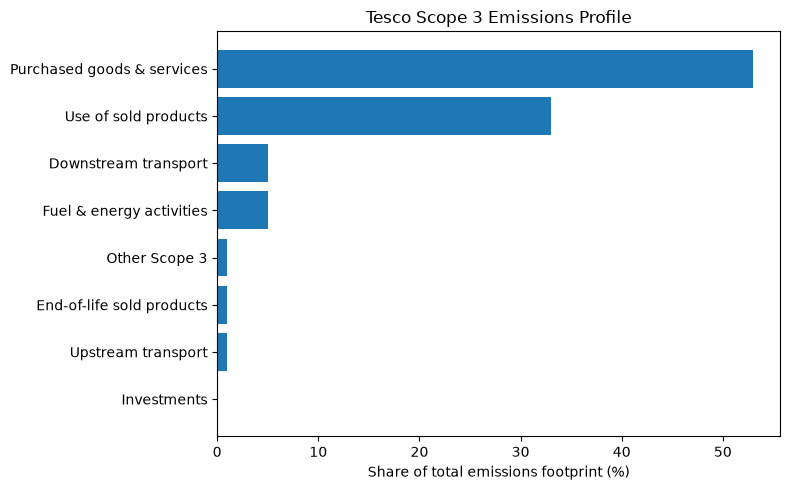

In [10]:
import matplotlib.pyplot as plt

tesco_scope3_sorted = tesco_scope3.sort_values(
    "footprint_pct",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    tesco_scope3_sorted["category"],
    tesco_scope3_sorted["footprint_pct"]
)

plt.xlabel("Share of total emissions footprint (%)")
plt.title("Tesco Scope 3 Emissions Profile")

plt.tight_layout()
plt.show()

**Interpretation**

Tesco's emissions footprint is highly concentrated in its value chain.
Purchased goods and services (53%) and use of sold products (33%) together
account for 86% of the total footprint.

This indicates that Tesco's largest decarbonisation opportunities lie beyond
its direct operations.

### 2.3 Sainsbury's Scope 3 Hotspots

Scope 3 accounts for 98% of Sainsbury's total emissions footprint.
Its Scope 3 strategy focuses on purchased goods for resale, transport
and consumer use.